In [ ]:
# Optional
# %pip install -q torch torchvision pandas pillow matplotlib

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms, models

# ============================================================
# Settings
# ============================================================

MODEL_PATH = Path("outputs/models/MOS_guess_validation_resnet50_aspect384x512_best.pth")
MODEL_NAME = "resnet50"

# Must match training preprocessing
INPUT_HEIGHT = 384
INPUT_WIDTH = 512

IMAGE_DIR = Path("new_images")
OUTPUT_CSV = Path("outputs/results/inference_predictions_resnet50_aspect384x512.csv")
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

CLIP_TO_RANGE = True
MOS_MIN = 1.0
MOS_MAX = 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device      :", DEVICE)
print("MODEL_PATH  :", MODEL_PATH.resolve())
print("IMAGE_DIR   :", IMAGE_DIR.resolve())
print("INPUT SIZE  :", (INPUT_HEIGHT, INPUT_WIDTH))

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH.resolve()}")

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image folder not found: {IMAGE_DIR.resolve()}")

Device      : cuda
MODEL_PATH  : /home/sagemaker-user/Sprint 2/Stage 2/outputs/models/MOS_guess_validation_resnet50_aspect384x512_best.pth
IMAGE_DIR   : /home/sagemaker-user/Sprint 2/Stage 2/new_images
INPUT SIZE  : (384, 512)


In [3]:
# ============================================================
# Build model and preprocessing
# ============================================================

def build_model(model_name: str):
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model

infer_transform = transforms.Compose([
    transforms.Resize((INPUT_HEIGHT, INPUT_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def load_model(model_path, model_name, device):
    model = build_model(model_name).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def gather_image_paths(folder: Path):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
    return sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in valid_exts])

def predict_one_image(model, image_path, device):
    image = Image.open(image_path).convert("RGB")
    x = infer_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).squeeze(1).item()

    pred_raw = float(pred)
    pred_final = float(np.clip(pred_raw, MOS_MIN, MOS_MAX)) if CLIP_TO_RANGE else pred_raw
    return pred_raw, pred_final

model = load_model(MODEL_PATH, MODEL_NAME, DEVICE)
print("Model loaded successfully.")

Model loaded successfully.


In [4]:
# ============================================================
# Run inference for all images in new_images
# ============================================================

image_paths = gather_image_paths(IMAGE_DIR)

if len(image_paths) == 0:
    raise FileNotFoundError(f"No supported image files found in: {IMAGE_DIR.resolve()}")

rows = []
for img_path in image_paths:
    raw_score, final_score = predict_one_image(model, img_path, DEVICE)
    rows.append({
        "image_name": img_path.name,
        "image_path": str(img_path),
        "predicted_score_raw": raw_score,
        "predicted_score_final": final_score
    })

pred_df = pd.DataFrame(rows).sort_values(
    by="predicted_score_final",
    ascending=False
).reset_index(drop=True)

pred_df.to_csv(OUTPUT_CSV, index=False)

print(f"Total images inferred: {len(pred_df)}")
print(f"Saved CSV to: {OUTPUT_CSV.resolve()}")
display(pred_df)

Total images inferred: 5
Saved CSV to: /home/sagemaker-user/Sprint 2/Stage 2/outputs/results/inference_predictions_resnet50_aspect384x512.csv


,image_name,image_path,predicted_score_raw,predicted_score_final
0,image-5.webp,new_images/image-5.webp,3.586387,3.586387
1,image-4.webp,new_images/image-4.webp,3.216184,3.216184
2,image-7.jpg,new_images/image-7.jpg,2.723654,2.723654
3,image-2.webp,new_images/image-2.webp,2.340126,2.340126
4,image-6.jpg,new_images/image-6.jpg,2.235940,2.235940


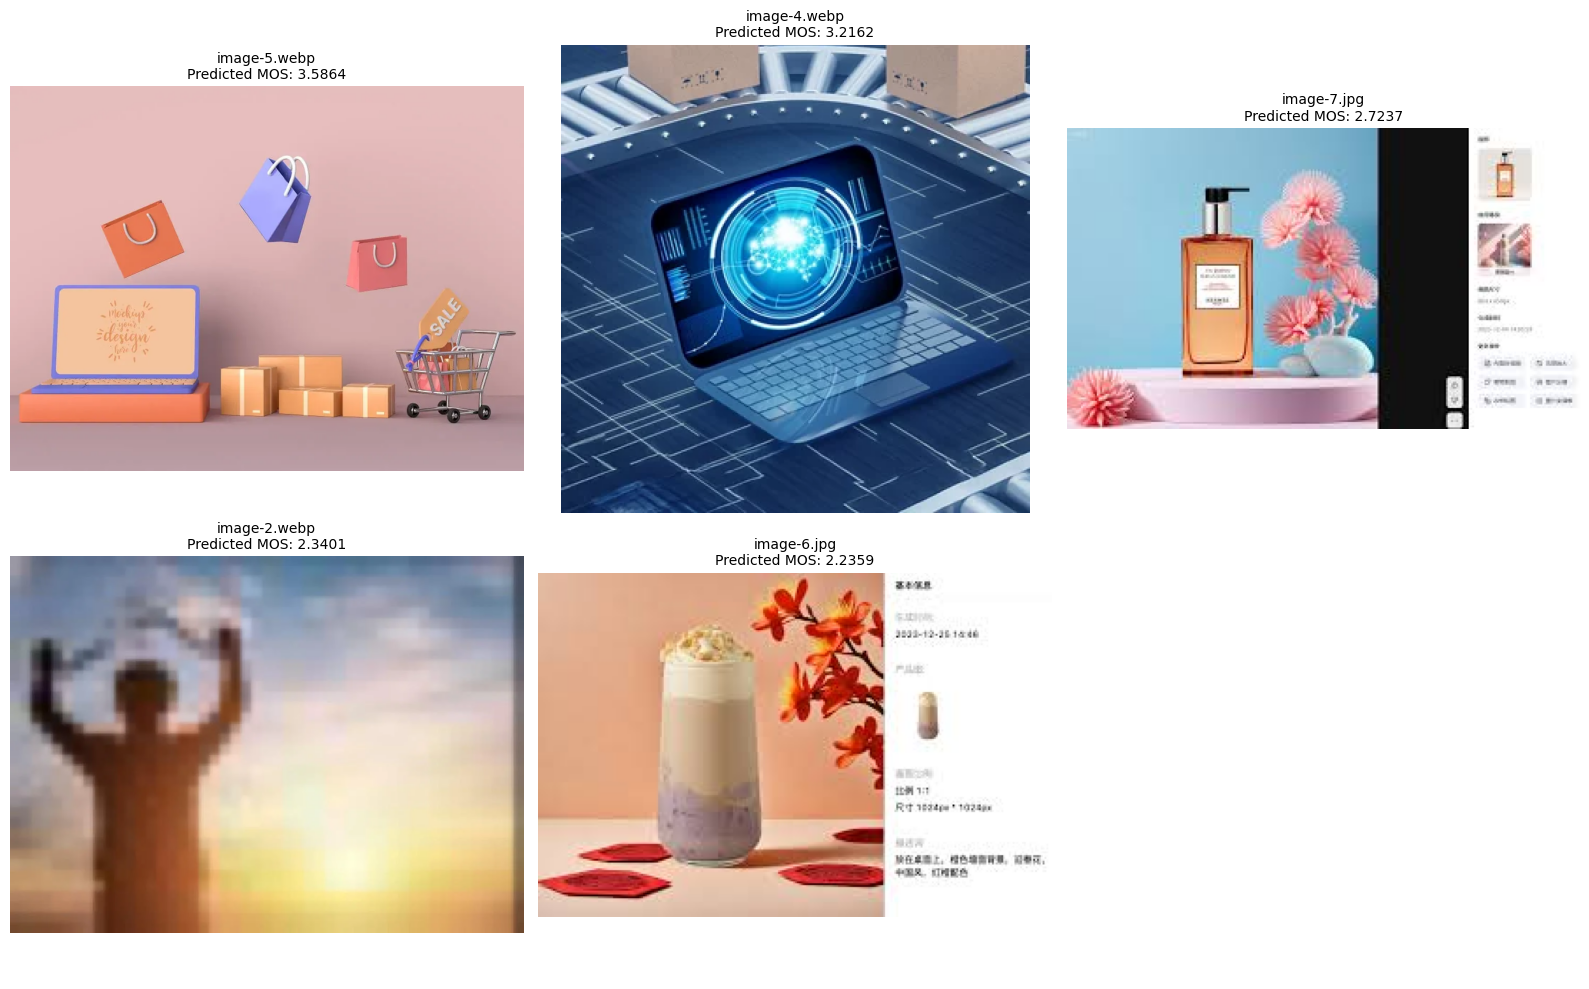

In [5]:
# ============================================================
# Show all results as images with predicted scores
# ============================================================

n_show = len(pred_df)
cols = 3
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, pred_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"{row['image_name']}\n"
        f"Predicted MOS: {row['predicted_score_final']:.4f}",
        fontsize=10
    )
    ax.axis("off")

for ax in axes[len(pred_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Optional: quick summary
print("Prediction summary:")
print(pred_df["predicted_score_final"].describe())

Prediction summary:
count    5.000000
mean     2.820458
std      0.575543
min      2.235940
25%      2.340126
50%      2.723654
75%      3.216184
max      3.586387
Name: predicted_score_final, dtype: float64
